

The objective of this assignment is **not to use a CNN**, but instead to solve the classification problem using a **classical machine learning approach**.  
For this reason, this notebook applies a traditional computer vision and machine learning pipeline to classify images as either cats or dogs.

The pipeline includes:

- **HOG** for capturing shape and edge information
- **LBP** for extracting texture features
- **Color histograms** for representing color information
- **StandardScaler + PCA** for preprocessing and dimensionality reduction
- **SVC** for binary classification

Why SVM?
SVMwaschosen because it is well suited to binary classification problems with high-dimensional
handcrafted features such as HOG, LBP, and color histograms. Compared with simpler models
such as Logistic Regression, SVM can better handle more complex decision boundaries, espe
cially when using an RBF kernel. It is also a strong classical machine learning method that
often performs well when the data representation is based on feature extraction rather than
deep learning.

The required function for the assignment is:

```python
cats_dogs_classification(image)
# Cats vs Dogs Classification (Classical ML)





## 1. Imports


In [1]:

import os
import warnings
from pathlib import Path

import joblib
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from skimage.color import rgb2gray
from skimage.feature import hog, local_binary_pattern

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
np.random.seed(42)



## 2. Configuration

Edit `DATA_DIR` only if needed.


In [ ]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')



DATA_DIR = Path("DATA")
CAT_DIR = DATA_DIR / 'Cat'
DOG_DIR = DATA_DIR / 'Dog'

IMG_SIZE = (128, 128)
RANDOM_STATE = 42
MODEL_PATH = '/content/drive/MyDrive/cats_dogs_model.joblib'

print("Using DATA_DIR:", DATA_DIR)
print("Cat folder exists:", CAT_DIR.exists())
print("Dog folder exists:", DOG_DIR.exists())


Mounted at /content/drive
Using DATA_DIR: /content/drive/MyDrive/DATA
Cat folder exists: True
Dog folder exists: True



## 3. Load the dataset


In [3]:

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png",}


def get_image_paths_and_labels(data_dir: Path):
    cat_dir = data_dir / "Cat"
    dog_dir = data_dir / "Dog"

    if not cat_dir.exists() or not dog_dir.exists():
        raise FileNotFoundError(
            "Dataset not found. Expected folders: DATA/Cat and DATA/Dog"
        )

    image_paths = []
    labels = []

    for label_name, label_value in [("Cat", 0), ("Dog", 1)]:
        folder = data_dir / label_name
        for file_path in sorted(folder.iterdir()):
            if file_path.suffix.lower() in VALID_EXTENSIONS:
                image_paths.append(file_path)
                labels.append(label_value)

    return np.array(image_paths), np.array(labels)


image_paths, labels = get_image_paths_and_labels(DATA_DIR)

print(f"Total images: {len(image_paths)}")
print(f"Cats: {(labels == 0).sum()}")
print(f"Dogs: {(labels == 1).sum()}")


Total images: 18770
Cats: 9381
Dogs: 9389



## 4. Visualize a few samples


In [4]:

VALID_EXTENSIONS = {".jpg", ".jpeg", ".png"}


def get_image_paths_and_labels(data_dir: Path):
    cat_dir = data_dir / "Cat"
    dog_dir = data_dir / "Dog"

    if not cat_dir.exists() or not dog_dir.exists():
        raise FileNotFoundError(
            "Dataset not found. Expected folders: DATA/Cat and DATA/Dog"
        )

    image_paths = []
    labels = []

    for label_name, label_value in [("Cat", 0), ("Dog", 1)]:
        folder = data_dir / label_name
        for file_path in sorted(folder.iterdir()):
            if file_path.suffix.lower() in VALID_EXTENSIONS:
                image_paths.append(file_path)
                labels.append(label_value)

    return np.array(image_paths), np.array(labels)


image_paths, labels = get_image_paths_and_labels(DATA_DIR)

print(f"Total images: {len(image_paths)}")
print(f"Cats: {(labels == 0).sum()}")
print(f"Dogs: {(labels == 1).sum()}")


Total images: 18770
Cats: 9381
Dogs: 9389



## 5. Feature extraction

We combine three families of features:

1. **HOG**: captures edges and global shape structure.
2. **LBP**: captures texture patterns.
3. **Color histogram**: captures color distribution.

This is a good classical ML choice because cats and dogs differ in **shape**, **fur texture**, and **color distribution**.


In [5]:

def load_rgb_image(image_path, size=IMG_SIZE):
    img = Image.open(image_path).convert("RGB")
    img = img.resize(size)
    return np.array(img)


def extract_hog_features(image_rgb):
    gray = rgb2gray(image_rgb)
    features = hog(
        gray,
        orientations=9,
        pixels_per_cell=(16, 16),
        cells_per_block=(2, 2),
        block_norm="L2-Hys",
        transform_sqrt=True,
        feature_vector=True,
    )
    return features


def extract_lbp_features(image_rgb, radius=1, n_points=8):
    gray = (rgb2gray(image_rgb) * 255).astype(np.uint8)
    lbp = local_binary_pattern(gray, n_points, radius, method="uniform")
    n_bins = n_points + 2
    hist, _ = np.histogram(lbp.ravel(), bins=np.arange(0, n_bins + 1), density=True)
    return hist


def extract_color_histogram(image_rgb, bins=8):
    hist_features = []
    for ch in range(3):
        hist, _ = np.histogram(image_rgb[:, :, ch], bins=bins, range=(0, 256), density=True)
        hist_features.extend(hist)
    return np.array(hist_features)


def extract_features_from_array(image_rgb):
    image_rgb = np.array(Image.fromarray(image_rgb).resize(IMG_SIZE))
    hog_feat = extract_hog_features(image_rgb)
    lbp_feat = extract_lbp_features(image_rgb)
    color_feat = extract_color_histogram(image_rgb)
    return np.concatenate([hog_feat, lbp_feat, color_feat]).astype(np.float32)


def extract_features_from_path(image_path):
    image_rgb = load_rgb_image(image_path)
    return extract_features_from_array(image_rgb)



## 6. Build the feature matrix


In [6]:

X = np.array([extract_features_from_path(path) for path in image_paths])
y = labels.copy()

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Feature matrix shape: (18770, 1798)
Labels shape: (18770,)


In [ ]:
np.save('/content/drive/MyDrive/X_features_.npy', X)
np.save('/content/drive/MyDrive/y_labels_.npy', y)

print("Saved X and y to Google Drive")


## 7. Train / validation split

The statement says the provided data is training data, so we split it into:
- **train set**: used to fit the model
- **validation set**: used to evaluate our choices before the professor tests on unseen data


In [7]:

X_train, X_val, y_train, y_val, train_paths, val_paths = train_test_split(
    X,
    y,
    image_paths,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Train set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)


Train set: (15016, 1798) (15016,)
Validation set: (3754, 1798) (3754,)



## 8. Train the classifier

We use a pipeline:

- **StandardScaler** because SVM works better when features are normalized
- **PCA** to reduce feature dimensionality and remove redundancy
- **SVC** because it usually performs well on medium-sized classical feature vectors


In [8]:

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=0.95, random_state=RANDOM_STATE)),
    ("svc", SVC(kernel="rbf", probability=False, class_weight="balanced", random_state=RANDOM_STATE)),
])

param_grid = {
    "svc__C": [1, 5, 10],
    "svc__gamma": ["scale", 0.01, 0.001],
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring="accuracy",
    cv=3,
    n_jobs=-1,
    verbose=1,
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", round(grid.best_score_, 4))


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best parameters: {'svc__C': 5, 'svc__gamma': 'scale'}
Best CV accuracy: 0.8003



## 9. Validation results


In [10]:
np.save('/content/drive/MyDrive/X_features_.npy', X)
np.save('/content/drive/MyDrive/y_labels_.npy', y)

y_pred = best_model.predict(X_val)

acc = accuracy_score(y_val, y_pred)
prec = precision_score(y_val, y_pred)
rec = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)

print(f"Validation Accuracy : {acc:.4f}")
print(f"Validation Precision: {prec:.4f}")
print(f"Validation Recall   : {rec:.4f}")
print(f"Validation F1-score : {f1:.4f}")

print("\nClassification report:")
print(classification_report(y_val, y_pred, target_names=["Cat", "Dog"]))

Validation Accuracy : 0.8029
Validation Precision: 0.8086
Validation Recall   : 0.7939
Validation F1-score : 0.8012

Classification report:
              precision    recall  f1-score   support

         Cat       0.80      0.81      0.80      1876
         Dog       0.81      0.79      0.80      1878

    accuracy                           0.80      3754
   macro avg       0.80      0.80      0.80      3754
weighted avg       0.80      0.80      0.80      3754



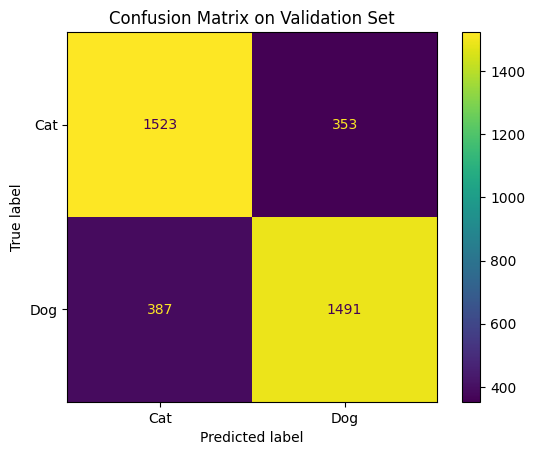

In [20]:

cm = confusion_matrix(y_val, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Cat", "Dog"])
disp.plot(values_format="d")
plt.title("Confusion Matrix on Validation Set")
plt.savefig('/content/drive/MyDrive/Confusion_Matrix.png', bbox_inches='tight')
plt.show()





## 10. Save the trained model


In [12]:

joblib.dump(best_model, MODEL_PATH)
print(f"Model saved to: {MODEL_PATH}")


Model saved to: /content/drive/MyDrive/cats_dogs_model.joblib



## 11. Required function: `cats_dogs_classification(image)`

This function:
- takes one image as input
- returns `0` for Cat or `1` for Dog

It accepts:
- a file path (`str` or `Path`)
- a `numpy.ndarray`
- a `PIL.Image.Image`


In [13]:

MODEL = best_model


def _to_rgb_array(image):
    if isinstance(image, (str, Path)):
        img = Image.open(image).convert("RGB")
        return np.array(img)

    if isinstance(image, Image.Image):
        return np.array(image.convert("RGB"))

    if isinstance(image, np.ndarray):
        arr = image
        if arr.ndim == 2:
            arr = np.stack([arr] * 3, axis=-1)
        if arr.ndim == 3 and arr.shape[2] == 4:
            arr = arr[:, :, :3]
        if arr.dtype != np.uint8:
            arr = np.asarray(arr, dtype=np.float32)
            if arr.max() <= 1.0:
                arr = arr * 255.0
            arr = np.clip(arr, 0, 255).astype(np.uint8)
        return arr

    raise TypeError("Input must be a path, PIL image, or numpy array")


def cats_dogs_classification(image):
    global MODEL

    if MODEL is None:
        if not os.path.exists(MODEL_PATH):
            raise FileNotFoundError(
                "No trained model found. Run the training cells first or keep cats_dogs_model.joblib in the same folder."
            )
        MODEL = joblib.load(MODEL_PATH)

    image_rgb = _to_rgb_array(image)
    features = extract_features_from_array(image_rgb).reshape(1, -1)
    prediction = MODEL.predict(features)[0]
    return int(prediction)
